In [265]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay, make_scorer
import matplotlib.pyplot as plt
from rbfnn_model import RBFNN
import pandas as pd
from sklearn import metrics
import numpy as np

In [266]:
data = pd.read_csv('finaldata.csv', header=None)
df = pd.DataFrame(data)
df

,0,1,2,3
0,-10.0,-0.500000,-10.0,-0.500000
1,-9.5,-0.485000,-9.9,-0.497000
2,-9.0,-0.470000,-9.8,-0.494000
3,-8.5,-0.455000,-9.7,-0.491000
4,-8.0,-0.440000,-9.6,-0.488000
5,-7.5,-0.425000,-9.5,-0.485000
6,-7.0,-0.410000,-9.4,-0.482000
7,-6.5,-0.395001,-9.3,-0.479000
8,-6.0,-0.380004,-9.2,-0.476000
9,-5.5,-0.365010,-9.1,-0.473000


In [267]:
# data_test = pd.read_csv('testdata.csv', header=None)
# df_test = pd.DataFrame(data_test)
# df_test

In [268]:
# X = df[[0]]
# y = df[[1]].values.reshape(-1, 1)

# # Split into train and test sets
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# # Standardize the data
# scaler = StandardScaler()
# X_train = scaler.fit_transform(X_train)
# X_test = scaler.transform(X_test)

In [276]:
X_train = df[[0]]
y_train = df[[1]].values.reshape(-1,1)
X_test = df[[2]]
y_test = df[[3]].values.reshape(-1,1)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [277]:
# X_train = df[[0]]
# y_train = df[[1]].values.reshape(-1,1)
# X_test = df_test[[0]]
# y_test = df_test[[1]].values.reshape(-1,1)

# scaler = StandardScaler()
# X_train = scaler.fit_transform(X_train)
# X_test = scaler.transform(X_test)

In [278]:
# Initialize and train the RBFNN
rbfnn = RBFNN(num_centers=20)
rbfnn.fit(X_train, y_train)

In [279]:
y_pred = rbfnn.predict(X_test)

In [280]:
#compairing predicted valiues with the actual values by metricses
print("Mean Absolute Error: ", metrics.mean_absolute_error(y_test, y_pred))
print("Mean Squared Error: ", metrics.mean_squared_error(y_test, y_pred))
print("Root Mean Squared Error: ", np.sqrt(metrics.mean_squared_error(y_test, y_pred)))

Mean Absolute Error:  4.318049276381648
Mean Squared Error:  24.003306316458136
Root Mean Squared Error:  4.899316923455569


In [281]:
from rbfnn_best_model import RBFNetwork

# تعیین مراکز به صورت تصادفی
centers = X_train[np.random.choice(len(X_train), size=10, replace=False)]
sigma = 0.5
l2_reg = 0.05

model = RBFNetwork(centers, sigma)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [282]:
#compairing predicted valiues with the actual values by metricses
print("Mean Absolute Error: ", metrics.mean_absolute_error(y_test, y_pred))
print("Mean Squared Error: ", metrics.mean_squared_error(y_test, y_pred))
print("Root Mean Squared Error: ", np.sqrt(metrics.mean_squared_error(y_test, y_pred)))

Mean Absolute Error:  0.011723914456623375
Mean Squared Error:  0.00016709898349030077
Root Mean Squared Error:  0.012926677202216384


In [252]:
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error

# 2. تقسیم داده‌ها به ورودی و خروجی
X_train = df[0].values.reshape(-1, 1)
y_train = df[1].values


In [253]:
# 3. تعریف و آموزش مدل RBF با SVR
rbf_svr = SVR(kernel="rbf", C=100, gamma=0.1, epsilon=0.01)
rbf_svr.fit(X_train, y_train)

SVR(C=100, epsilon=0.01, gamma=0.1)

In [254]:
# 4. پیش‌بینی مقادیر جدید
X_test = np.linspace(X_train.min(), X_train.max(), 100).reshape(-1, 1)
y_pred = rbf_svr.predict(X_test)

In [255]:
# 5. محاسبه خطا
mse = mean_squared_error(y_train, rbf_svr.predict(X_train))
print(f"Mean Squared Error: {mse:.6f}")

Mean Squared Error: 0.003042


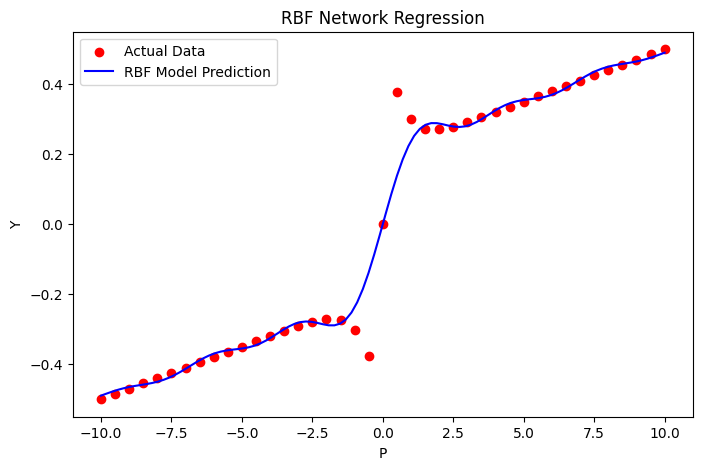

In [256]:
plt.figure(figsize=(8, 5))
plt.scatter(X_train, y_train, color='red', label='Actual Data')
plt.plot(X_test, y_pred, color='blue', label='RBF Model Prediction')
plt.xlabel("P")
plt.ylabel("Y")
plt.title("RBF Network Regression")
plt.legend()
plt.show()

In [257]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error

In [258]:
# 2. مقیاس‌بندی داده‌ها
scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(df[[0, 1]])
X_scaled = data_scaled[:, 0].reshape(-1, 1, 1)
y_scaled = data_scaled[:, 1]

In [259]:
# 3. تعریف مدل RNN
model = Sequential([
    SimpleRNN(50, activation='tanh', return_sequences=False, input_shape=(1, 1)),
    Dense(1)
])
model.compile(optimizer='adam', loss='mse')

/Users/aminmehri/Projects/uni_project/venv/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [260]:
# 4. آموزش مدل
model.fit(X_scaled, y_scaled, epochs=100, batch_size=8, verbose=1)

Epoch 1/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 892us/step - loss: 0.3939
Epoch 2/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 796us/step - loss: 0.3250
Epoch 3/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 797us/step - loss: 0.2467
Epoch 4/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 764us/step - loss: 0.1598
Epoch 5/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 876us/step - loss: 0.1173
Epoch 6/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 917us/step - loss: 0.0928
Epoch 7/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 892us/step - loss: 0.0693
Epoch 8/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 807us/step - loss: 0.0603
Epoch 9/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 754us/step - loss: 0.0633
Epoch 10/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 766us/step - loss: 0.0578
Epoch 11/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 737us/step - loss: 0.0547
Epoch 12/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 787us/step - loss: 0.0477
Epoch 13/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 755us/step - loss: 0.0484
Epoch 14/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 752us/step - loss: 0.0522
Epoch 15/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 898us/step - loss: 0.0450
Epoc

In [261]:
# 5. پیش‌بینی مقادیر جدید
X_test = np.linspace(X_scaled.min(), X_scaled.max(), 100).reshape(-1, 1, 1)
y_pred_scaled = model.predict(X_test)
y_pred = scaler.inverse_transform(np.hstack((X_test.reshape(-1, 1), y_pred_scaled.reshape(-1, 1))))[:, 1]

1/4 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/stepWARNING:tensorflow:5 out of the last 13 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x171d4c540> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step


In [262]:
# 6. محاسبه خطا
mse = mean_squared_error(data[1], scaler.inverse_transform(np.hstack((X_scaled.reshape(-1, 1), model.predict(X_scaled).reshape(-1, 1))))[:, 1])
print(f"Mean Squared Error: {mse:.6f}")

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
Mean Squared Error: 0.015311


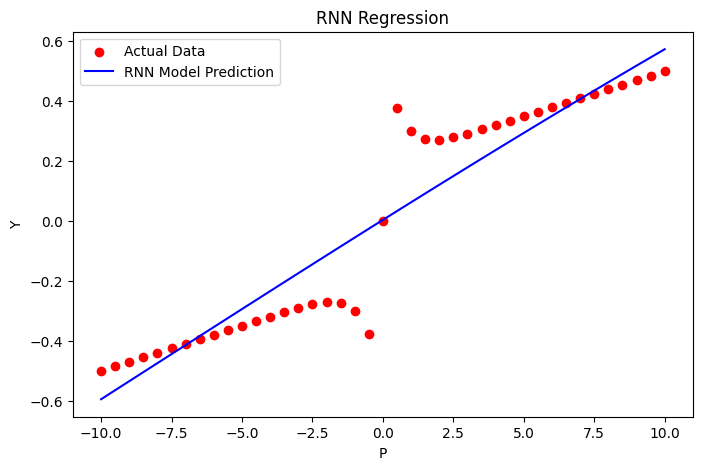

In [263]:
# 7. نمایش نتایج
plt.figure(figsize=(8, 5))
plt.scatter(df[0], df[1], color='red', label='Actual Data')
plt.plot(np.linspace(df[0].min(), df[0].max(), 100), y_pred, color='blue', label='RNN Model Prediction')
plt.xlabel("P")
plt.ylabel("Y")
plt.title("RNN Regression")
plt.legend()
plt.show()

In [264]:
import numpy as np
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import mean_squared_error, make_scorer
from sklearn.base import BaseEstimator

# تعریف توابع RBF و کلاس RBFNetwork
def gaussian_rbf(x, c, sigma):
    return np.exp(-np.linalg.norm(x - c)**2 / (2 * sigma**2))

class RBFNetwork:
    def __init__(self, centers, sigma=1.0, l2_reg=0.0):
        self.centers = centers
        self.sigma = sigma
        self.l2_reg = l2_reg
        self.weights = None

    def _design_matrix(self, X):
        return np.array([[gaussian_rbf(x, c, self.sigma) for c in self.centers] for x in X])

    def fit(self, X, y):
        phi = self._design_matrix(X)
        if self.l2_reg > 0:
            reg_matrix = self.l2_reg * np.eye(phi.shape[1])
            self.weights = np.linalg.lstsq(phi.T @ phi + reg_matrix, phi.T @ y, rcond=None)[0]
        else:
            self.weights = np.linalg.lstsq(phi.T @ phi, phi.T @ y, rcond=None)[0]

    def predict(self, X):
        phi = self._design_matrix(X)
        return phi @ self.weights

# تابع برای محاسبه خطای مدل (MSE)
def mse_score(y_true, y_pred):
    return mean_squared_error(y_true, y_pred)

# ایجاد یک wrapper برای استفاده از RBFNetwork در GridSearchCV
class RBFNetworkWrapper(BaseEstimator):
    def __init__(self, centers, sigma=1.0, l2_reg=0.0):
        self.centers = centers
        self.sigma = sigma
        self.l2_reg = l2_reg
        self.model = RBFNetwork(centers, sigma=sigma, l2_reg=l2_reg)

    def fit(self, X, y):
        self.model.fit(X, y)
        return self

    def predict(self, X):
        return self.model.predict(X)

    # پیاده‌سازی متد get_params
    def get_params(self, deep=True):
        return {
            'centers': self.centers,
            'sigma': self.sigma,
            'l2_reg': self.l2_reg
        }

    # پیاده‌سازی متد set_params
    def set_params(self, **params):
        for key, value in params.items():
            setattr(self, key, value)
        self.model = RBFNetwork(self.centers, sigma=self.sigma, l2_reg=self.l2_reg)
        return self

# تعریف پارامترهای جستجوی گرید
param_grid = {
    'sigma': [0.01, 0.1, 0.5, 1.0, 2.0, 5.0, 10.0],  # مقادیر بیشتر برای sigma
    'l2_reg': [0.0, 0.0001, 0.001, 0.01, 0.1, 1.0, 10.0]  # مقادیر بیشتر برای تنظیم L2
}

X_train = df[[2]]
y_train = df[[3]].values.reshape(-1,1)
X_test = df[[0]]
y_test = df[[1]].values.reshape(-1,1)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

centers = X_train[np.random.choice(len(X_train), size=10, replace=False)]

# ایجاد مدل
model = RBFNetworkWrapper(centers)

# ایجاد GridSearchCV
grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    scoring=make_scorer(mse_score, greater_is_better=False),
    cv=5,  # تعداد folds در اعتبارسنجی متقابل
    n_jobs=-1  # استفاده از تمام هسته‌های CPU
)

# اجرای جستجوی گرید
grid_search.fit(X_train, y_train)

# بهترین پارامترها
print("Best parameters found: ", grid_search.best_params_)

# ارزیابی مدل با بهترین پارامترها روی داده‌های تست
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)
mse = mse_score(y_test, y_pred)
print(f"Mean Squared Error on test set: {mse}")

Best parameters found:  {'l2_reg': 0.0, 'sigma': 5.0}
Mean Squared Error on test set: 0.07454330465911013
